In [189]:
import re
import pandas as pd
from pathlib import Path
import requests
from bs4 import BeautifulSoup
import seaborn as sns
import numpy as np
import networkx as nx
from PIL import Image
from matplotlib import pyplot as plt

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_colwidth', 500)

In [3]:
# ---- Analysis configuration -------------------------------------------------
# To run a new round: bump FY and re-run top to bottom. Every input and output
# path below derives from it. See ../ANALYSIS.md for what else a round needs
# (roster reconciliation, PI photos) that is not just a matter of paths.

FY = 2025        # fiscal year of the annual reports being analyzed
PREV_FY = 2021   # previous round, for the trend comparison

data_path = Path('../data/')
fig_path = Path('../figures') / f'FY{FY}'
fig_path.mkdir(parents=True, exist_ok=True)

# Derived tables, FY-stamped so rounds no longer overwrite each other.
project_table = data_path / f'pj_df_FY{FY}.csv'      # one row per annual report
collab_table = data_path / f'pi_collabs_FY{FY}.csv'  # one row per reported collaboration

# ipid discovery. The FY2018 and FY2021 rounds read ipids out of a search
# results page saved by hand from intramural.nih.gov. That browse path is gone:
# search now requires search terms, so there is no "list all NIMH reports for
# year X" request to save. FY2025 discovery is rewritten in the next cells.
# These files are kept so FY2021 can be re-run as a regression test.
LEGACY_SEARCH_HTML = {2018: 'nidb_nimh_search_2018_11_07.htm',
                      2021: 'nidb_nimh_search_2021_09_09.html'}

if FY in LEGACY_SEARCH_HTML:
    search_res_html = (data_path / LEGACY_SEARCH_HTML[FY]).read_text()
else:
    search_res_html = None  # FY2025+: ipids come from the discovery scan below


In [4]:
# Fetch and parse the annual reports. Scraping lives in ../nidb.py now — the
# inline parser this replaced targeted markup that no longer exists (see
# ../ANALYSIS.md). Fetches are cached per-FY; delete the cache to re-fetch.
import sys
sys.path.insert(0, '..')
import nidb

In [272]:
# ipids for the year. FY2025's list comes from data/nimh_fy2025_ipids.csv (see
# its .md sidecar for provenance); earlier years fall back to the ipid links in
# the hand-saved search page.
import json

if FY == 2025:
    ipids = pd.read_csv(data_path / 'nimh_fy2025_ipids.csv').ipid.astype(str).tolist()
else:
    ipids = pd.unique(np.array(re.findall(ipid_pat := re.compile(r'\?ipid=([0-9]*)'), search_res_html)))
print(f'{len(ipids)} reports for FY{FY}')

In [273]:
scrape_cache = data_path / f'fy{FY}_scrape_cache.json'
if scrape_cache.exists():
    pjdf = json.loads(scrape_cache.read_text())
    print(f'loaded {len(pjdf)} reports from {scrape_cache.name}')
else:
    pjdf, scrape_errors = nidb.scrape_reports(ipids, expect_fy=FY, delay=0.5)
    assert not scrape_errors, scrape_errors
    scrape_cache.write_text(json.dumps(pjdf, indent=1))

In [274]:
pj_df = pd.DataFrame(pjdf)

In [8]:
pj_df.to_pickle(data_path / f'pj_df_FY{FY}.pkl')

In [9]:
pj_df.to_csv(project_table)

In [275]:
col_rn = {'Collaborators from other NIH organizations': 'NIH_collab',
          'Collaborators from other NIMH organizations': 'NIMH_collab',
          'External Collaborators': 'EM_collab'}
pj_df = pj_df.rename(columns=col_rn)

In [276]:
pj_df['Research Organization'] = pj_df['Research Organization'].str.strip()

In [277]:
pj_df['PI'] = pj_df['Principal Investigator'].str.strip().str.split('\n').str[0]
pj_df['PI'] = pj_df['PI'].fillna(pj_df['Lead Investigator'].str.strip())

In [278]:
pj_df['pj_text'] = pj_df['Goals and Objectives'] + pj_df['Summary']

In [161]:
pj_df

,pj_num,Report Title,2021 Fiscal Year,Principal Investigator,Research Organization,Lab Staff and Collaborators,NIH_collab,External Collaborators,Keywords,Goals and Objectives,Summary,Publications Generated,NIMH_collab,Lead Investigator,Supervisor of Record,PI
0,MH000889-42,Dysregulation of Protein Synthesis in Fragile X Syndrome and Other Developmental Disorders,"October 01, 2020 - September 30, 2021","Carolyn E Smith, PhD",Section on Neuro-adaptation and Protein Metabolism,"[Inna Loutaev, DNP, Kathleen Colette Schmidt, MA, Tianjian Huang, MS, Thomas Burlin, BSc, Rachel Michelle Reith, PhD, Zengyan Xia, MBA]","[(Zenaide Maria Quezado, MD , CC)]","[(Mark Gurney, Tetra Therapeutics (United States))]","brain imaging, fragile X syndrome, protein synthesis, sleep, intellectual disability, tuberous sclerosis complex, amino acids, anxiety, leucine, plasticity, autism, dexmedetomidine, positron emission tomography, shank3, cAMP",Current data suggests links between autism and intellectual disability and defects in synaptic plasticity as seen in fragile X syndrome (FXS). Synaptic plasticity requires the exquisite temporal and spatial regulation of protein synthesis to ensure efficacious synaptic remodeling. Products of mutated genes in syndromic forms of autism point to a relationship between disrupted synaptic function and dysregulated protein metabolism. Our research on FXS in both rodent models and humans addresses...,"The work on humans was conducted under the protocol 06-M-0214, NCT00362843. During the 2021 funding period, we addressed the following:1) rCPS measured with the L-1-C-11leucine PET method in participants with FXS and healthy volunteers studied under dexmedetomidine sedation, 2) rCPS measured with the L-1-C-11leucine PET method in participants with FXS and healthy volunteers studied in the awake state, 3) protein synthesis rates in mouse models of other neurodevelopmental disorders, 4) mTOR...","Ordered by reference within the summary, then by publication type and author name.\n\n\n1. Schmidt KC, Loutaev I, Quezado Z, Sheeler C, Smith CB (2020). Regional rates of brain protein synthesis are unaltered in dexmedetomidine sedated young men with fragile X syndrome: A L-[1-11C]leucine PET study. Neurobiol Dis 143, 104978. https://doi.org/10.1016/j.nbd.2020.104978\n\nPubMed\n\n\nFree Article\n\n\n\n\n\n\n2. Saré RM, Lemons A, Figueroa C, Song A, Levine M, Beebe Smith C (2020). Sex-Sele...",NaN,NaN,NaN,"Carolyn E Smith, PhD"
1,MH001090-44,Studies of Central Nervous System Functional Anatomy,"October 01, 2020 - September 30, 2021","Miles Herkenham, PhD",Section on Functional Neroanatomy,"[Michael L Lehmann, PhD, Samuel J Listwak, PhD, Joshua David Samuels, Allison Emily Depuyt, Madison Lee Lotstein]","[(Abdel G Elkahloun, PhD , NHGRI)]","[(M Clatworthy, University of Cambridge, Department of Medicine, Laboratory of Molecular Biology)]","blood-brain barrier, microglia, neuroimmunology, depression, anxiety, cytokine, environmental enrichment, social behavior, lymphocytes, psychosocial stress, meninges, neutrophils, cerebrovascular","Risk factors for developing mental disorders include adverse life events such as psychosocial stress. Such stressors, especially when chronic, produce cellular changes in brain regions processing emotional content, contributing to altered affective behavior that underlies psychiatric mood disorders. Both sustained psychological stressors and related physiological challenges affect the brain directly and indirectly via interactions between the brain and the peripheral cardiovascular, endocrin...","Chronic psychosocial stress has been implicated in the etiology and progression of psychiatric disorders such as major depression and post-traumatic stress disorder (PTSD). We study the effects of psychosocial stress in a chronic social defeat (CSD) paradigm in mice that generates behavioral alterations manifested as social avoidance, anhedonia, anxiety, and depressive-like states. In CSD, two male mice are p

# cluster at research organization level

In [279]:
pj_df.loc[:,['PI', 'Research Organization', 'Report Title']]

,PI,Research Organization,Report Title
0,"Carolyn E Smith, PhD",Section on Neuro-adaptation and Protein Metabolism,Dysregulation of Protein Synthesis in Fragile X Syndrome and Other Developmental Disorders
1,"Miles Herkenham, PhD",Section on Functional Neroanatomy,Studies of Central Nervous System Functional Anatomy
2,"Barry J Richmond, MD",Section on Neural Coding and Computation,Neural Coding of Visual Stimuli
3,"Leslie G Ungerleider, PhD",Section on Neurocircuitry,Functional Anatomy of Perceptual and Attentional Systems in the Primate Brain
4,"Lee E Eiden, PhD",Section on Molecular Neuroscience,Chemical Coding of Neurotransmission
5,"Charles R Gerfen, PhD",Office of the Director,Functional Organization of the Cerebral Cortex and Basal Ganglia
6,"Walter Scott Young, MD, PhD, MPH",Section on Neural Gene Expression,Roles of Oxytocin and Vasopressin in Brain
7,"Peter J Schmidt, MD",Section on Behavioral Endocrinology,Psychobiology and Treatment of Perimenopausal Mood Disorders
8,"Alex Martin, PhD",Section on Cognitive Neuropsychology,The Neural Foundations for Memory and Social Cognition in the Human Brain
9,"Barry J Richmond, MD",Section on Neural Coding and Computation,Neural Mechanisms of Motivation and Reward


In [280]:
pj_df['Report Title'] = pj_df['Report Title'].str.strip()

In [281]:
# Reports filed under an umbrella organization, re-labeled to the team they
# actually describe so collaborator-listed org names can match them.
# (PI, Research Organization, Report Title) -> ro
# FY2025 needs fewer of these than FY2021: NIDB now records Gerfen, DSST, and
# the Machine Learning Core under their own organizations directly.
manual_edits = [('Susan G Amara, PhD', 'Office of the Director', 'Office of the Scientific Director', 'Office of the Scientific Director'),
                ('Susan G Amara, PhD', 'Office of the Director', 'NIMH Space Activation, Maintenance, and Improvement', 'Space Activation, Maintenance, and Improvement'),
                ('Susan G Amara, PhD', 'Office of the Director', 'Transgenic Resources for Neuroscience Research', 'Transgenic Core'),
                ('Maryland  Pao, BA, MD', 'Office of the Clinical Director', 'Psychiatry Clinical Research Training-NIMH Office of the Clinical Director', 'Psychiatry Clinical Research Training'),
                ('Audrey E Thurm, PhD', 'Office of the Clinical Director', 'Neurodevelopmental and Behavioral Phenotyping', 'Neurodevelopmental and Behavioral Phenotyping Service'),
                ('Ashura  Buckley, MD', 'Office of the Clinical Director', 'Sleep and Neurodevelopment Service', 'Sleep and Neurodevelopment Service'),
               ]

In [282]:
pj_df.loc[(pj_df['Research Organization'].isin(['Office of the Clinical Director',
                                                'Office of the Director',
                                                'Functional MRI Core'])), ['PI', 'Research Organization', 'Report Title']].PI.values

array(['Charles R Gerfen, PhD', 'Susan G Amara, PhD',
       'Maryland  Pao, BA, MD', 'Peter A Bandettini, BS, PhD',
       'Adam G Thomas, DPhil', 'Audrey E Thurm, PhD', 'Ashura  Buckley',
       'Francisco  Pereira, PhD', 'Maryland  Pao, BA, MD',
       'Maryland  Pao, BA, MD', 'Susan G Amara, PhD'], dtype=object)

In [283]:
pj_df['ro'] = pj_df['Research Organization']
for me in manual_edits:
    pj_df.loc[(pj_df['PI']==me[0]) & (pj_df['Research Organization']==me[1]) & (pj_df['Report Title']==me[2]), 'ro'] = me[3]

In [284]:
pj_df.loc[(pj_df['Research Organization'].isin(['Office of the Clinical Director',
                                                'Office of the Director',
                                                'Functional MRI Core'])), ['PI', 'Research Organization', 'ro', 'Report Title']]

,PI,Research Organization,ro,Report Title
5,"Charles R Gerfen, PhD",Office of the Director,Organization of the Cortex and Basal Ganglia,Functional Organization of the Cerebral Cortex and Basal Ganglia
42,"Susan G Amara, PhD",Office of the Director,Office of the Scientific Director,Office of the Scientific Director
45,"Maryland Pao, BA, MD",Office of the Clinical Director,Office of the Clinical Director,Office of the Clinical Director Clinical Services Research
73,"Peter A Bandettini, BS, PhD",Functional MRI Core,Functional MRI Core,Functional MRI Core Facility
82,"Adam G Thomas, DPhil",Functional MRI Core,Data Science and Sharing Team,Data Science and Sharing Team
83,"Audrey E Thurm, PhD",Office of the Clinical Director,Neurodevelopmental and Behavioral Phenotyping Service,Neurodevelopmental and Behavioral Phenotyping
84,Ashura Buckley,Office of the Clinical Director,Sleep and Neurodevelopment Service,Sleep and Neurodevelopment Service
86,"Francisco Pereira, PhD",Functional MRI Core,Machine Learning Team,Machine Learning Team
87,"Maryland Pao, BA, MD",Office of the Clinical Director,Office of the Clinical Director,Office of the Clinical Director-Core Activities
88,"Maryland Pao, BA, MD",Office of the Clinical Director,Psychiatry Clinical Research Training,Office of the Clinical Director-Psychiatry Clinical Research Training


In [285]:
pi_df = pj_df.groupby(['PI', 'ro'],as_index=False)[['pj_text']].sum()
pi_df['label'] =  pi_df['PI'].str.split(';').str[0].str.split(' ').str[-1] + ', '  + pi_df['ro'].str.replace(', NIMH', '').str.replace('Unit on ', '').str.replace('Section on the ', '').str.replace('Section on ', '').str.replace('Laboratory of ', '')


# Make network type figures based on collaborations

In [286]:
pi_collab = []

pi_gb = pj_df.groupby(['PI', 'ro'],as_index=False)
for (PI, ro),df in pi_gb:
    for collab_col in ['NIMH_collab', 'EM_collab', 'NIH_collab']:
        collab = df.loc[df[collab_col].notnull(), collab_col].values
        for pairs in collab:
            # nidb.parse_report already returns [name, institution] pairs
            for parts in pairs:
                pc = {}
                pc['pi'] = PI
                pc['ro'] = ro
                pc['collab'] = parts[0].strip()
                pc['institute'] = parts[1].strip()
                pc['scope'] = collab_col.split('_')[0]
                pi_collab.append(pc)

In [287]:
pc

{'pi': 'sarah Hollingsworth Lisanby, MD',
 'ro': 'Unit on Non-invasive Neuromodulation',
 'collab': 'Eric M Wassermann, MD',
 'institute': 'NINDS',
 'scope': 'NIH'}

In [288]:
pd.DataFrame(pi_collab)

,pi,ro,collab,institute,scope
0,"Adam G Thomas, DPhil",Data Science and Sharing Team,"Melissa A Brotman, PhD",Unit on Neuroscience and Novel Therapeutics,NIMH
1,"Adam G Thomas, DPhil",Data Science and Sharing Team,"Joyce Chung, MD",Office of the Clinical Director,NIMH
2,"Adam G Thomas, DPhil",Data Science and Sharing Team,"Robert Cox, PhD",Scientific and Statistical Computing Core,NIMH
3,"Adam G Thomas, DPhil",Data Science and Sharing Team,"Emily Suzanne Finn, PhD",Section on Functional Imaging Methods,NIMH
4,"Adam G Thomas, DPhil",Data Science and Sharing Team,"Michael David Gregory, MD",Section on Integrative Neuroimaging,NIMH
...,...,...,...,...,...
1095,"sarah Hollingsworth Lisanby, MD",Unit on Non-invasive Neuromodulation,"Leonardo G Cohen, MD",NINDS,NIH
1096,"sarah Hollingsworth Lisanby, MD",Unit on Non-invasive Neuromodulation,"Mark Hallett, MD",NINDS,NIH
1097,"sarah Hollingsworth Lisanby, MD",Unit on Non-invasive Neuromodulation,"Betty Jo Salmeron, MD",NIDA,NIH
1098,"sarah Hollingsworth Lisanby, MD",Unit on Non-invasive Neuromodulation,"Elliot Alan Stein, PhD",NIDA,NIH


In [289]:
pj_df.groupby('PI').ro.nunique()

PI
Adam G Thomas, DPhil                1
Alex  Martin, PhD                   1
Allison Carol Nugent, PhD           1
Arash  Afraz, PhD, MD               1
Argyrios  Stringaris, PhD           1
Armin  Raznahan, PhD                1
Ashura  Buckley                     1
Audrey E Thurm, PhD                 1
Barbara K Lipska, PhD               1
Barry J Richmond, MD                1
Benjamin H White, PhD               1
Bruno B Averbeck, PhD               1
Carlos Alberto Zarate, MD           1
Carolyn E Smith, PhD                1
Charles R Gerfen, PhD               1
Christian  Grillon, PhD             1
Christopher Ian Baker, PhD          1
Daniel  Pine, MD                    1
David A Leopold, PhD                2
Dietmar  Plenz, PhD                 1
Elisabeth Adams Murray, PhD         1
Elisha Prem Merriam, PhD            1
Ellen  Leibenluft, MD               1
Francis Joseph McMahon, MD          1
Francisco  Pereira, PhD             1
George Raphael Dold, MS             1
Heather A

In [290]:
pi_collab = pd.DataFrame(pi_collab)

In [291]:
np.unique(pi_collab[pi_collab['collab'].str.contains('Gerfen')].collab.values)

array(['Charles R Gerfen, PhD'], dtype=object)

In [292]:
# NIMH-scope collaborators whose listed organization is stale or wrong,
# mapped to their FY2025 organization. Rebuilt for FY2025 (Aug 2026): entries
# carried over from FY2021 were kept only if the name still appears and the
# target org still exists; the rest were re-resolved against the FY2025 PI
# roster and report staff lists. See ANALYSIS.md for the method.
collab_corrections=[
    ('Adam G Thomas, DPhil', 'Data Science and Sharing Team'),
    ('Alex  Martin, PhD', 'Section on Cognitive Neuropsychology'),
    ('Allison Carol Nugent, PhD', 'Magnetoencephalography Core'),
    ('Ana Rita Lourenco Inacio, PhD', 'Section on Functional Neural Circuits'),
    ('Ashura  Buckley, MD', 'Sleep and Neurodevelopment Service'),
    ('Audrey E Thurm, PhD', 'Neurodevelopmental and Behavioral Phenotyping Service'),
    ('Bruno B Averbeck, PhD', 'Section on Learning and Decision Making'),
    ('Carlos Alberto Zarate, MD', 'Section on Neurobiology and Treatment of Mood Disorders'),
    ('Charles R Gerfen, PhD', 'Section on Neuroanatomy'),
    ('Cristan Ann Farmer, PhD', 'Neurodevelopmental and Behavioral Phenotyping Service'),
    ('Daniel  Pine, MD', 'Section on Development and Affective Neuroscience'),
    ('Daniel P Eisenberg', 'Clinical and Translational Neuroscience Branch'),
    ('Dylan M Nielson, PhD', 'Machine Learning Core'),
    ('Elisabeth Adams Murray, PhD', 'Section on Neurobiology of Learning and Memory'),
    ('Elisha Prem Merriam, PhD', 'Computational Neuroimaging and Perception Team'),
    ('Elizabeth Day Ballard, PhD', 'Section on Neurobiology and Treatment of Mood Disorders'),
    ('Eric Allen Earl', 'Data Science and Sharing Team'),
    ('Francisco  Pereira, PhD', 'Machine Learning Core'),
    ('Heather A Cameron, PhD', 'Section on Neuroplasticity'),
    ('Ioline D Henter, MA', 'Section on PET Neuroimaging Sciences'),
    ('James M Pickel, PhD, AB', 'Transgenic Core'),
    ('Karen F Berman, MD', 'Clinical and Translational Neuroscience Branch'),
    ('Kathleen R Merikangas, PhD', 'Section on Developmental Genetic Epidemiology'),
    ('Lindsay Meredith Oberman, PhD', 'Unit on Non-invasive Neuromodulation'),
    ('Lu  Zhang', 'Section on Functional Neural Circuits'),
    ('Melissa A Brotman, PhD, BA', 'Unit on Neuroscience and Novel Therapeutics'),
    ('Michael David Gregory, MD', 'Clinical and Translational Neuroscience Branch'),
    ('Peter James Molfese, PhD', 'Functional MRI Core'),
    ('Samer Saleh Hattar, PhD', 'Section on Light and Circadian Rhythms'),
    ('Shruti A Japee, BS, MS, PhD', 'Section on Cognitive Neuropsychology'),
    ('Siani Monet Barbosa', 'Section on Functional Neural Circuits'),
    ('Simone Paula Haller', 'Section on Development and Affective Neuroscience'),
    ('Siyuan  Liu, PhD', 'Section on Developmental Neurogenomics'),
    ('Soohyun  Lee, PhD', 'Section on Functional Neural Circuits'),
    ('Sunday Michelle Francis', 'Unit on Non-invasive Neuromodulation'),
    ('Theodore B Usdin, MD, PhD', 'Systems Neuroscience Imaging Resource'),
    ('Tonya Jo Hanson White, PhD, MD', 'Section on Social and Cognitive Developmental Neuroscience'),
    ('Veronica Alicia Alvarez, PhD', 'Section on Neurobiology of Compulsive Behaviors'),
    ('Vinai  Roopchansingh, PhD', 'Functional MRI Core'),
    ('William Thomas Regenold, MD', 'Unit on Non-invasive Neuromodulation'),
    ('Yogita  Chudasama, PhD', 'Rodent Behavioral Core'),
    ('Zheng  Li, PhD', 'Section on Synapse Development Plasticity'),
    ('Zhi-De  Deng, PhD', 'Unit on Non-invasive Neuromodulation')
]

# NIMH-scope collaborators dropped from the network: extramural program staff,
# plus people on no FY2025 report as PI or lab staff (departed or retired --
# the stale carry-forward problem flagged in the 2022 round).
drop_list = [
    'Shelli  Avenevoli, PhD',
    'Andrea Horvath Marques',
    'Anna Elisa Ordonez, MD',
    'Michael  Schoenbaum, PhD',
    'Judith L Rapoport, MD',
    'Susan Elizabeth Swedo, MD',
    'Jiemin  Jia, PhD',
    'Jane  Pearson',
    'Leonardo  Cubillos',
    'Lisa J Colpe',
    'Collene  Lawhorn, PhD',
    'Argyrios  Stringaris, PhD',
    'Hanna  Keren',
    'Mark Eldridge, PhD',
    'B Sofia  Beas, PhD',
    'Corey Macneil Ziemba',
    'Jessica  De Faria Dafflon',
    'Sarah Hollingsworth Lisanby, MD',
    'Bridget Wilson Mahony',
    'Ellen  Leibenluft, MD',
    'Katharina  Kircanski',
    'Deborah Morgan Roberts',
    'Monique  Ernst, MD, PhD',
    'John E Ingeholm',
    'Andrew Rattin Mitz, BS, MS, PhD',
    'Dipta  Saha',
    'Grace Victoria Ringlein',
    'Lucrezia  Liuzzi',
    'Maria  Zelenina',
    'Song  Qi',
    'Jiazhou  Chen',
    'Kyunghun  Lee'
]

In [293]:
for name, correct_group in collab_corrections:
    pi_collab.loc[(pi_collab.collab == name) & (pi_collab.scope == 'NIMH'), 'institute'] = correct_group

pi_collab = pi_collab.loc[~(pi_collab.collab.isin(drop_list) & (pi_collab.scope == 'NIMH'))].copy()

In [55]:
#pj_df['section_only'] = pj_df.ro.str.replace(", NIMH", "")

In [197]:
#pj_df[pj_df['PI'].str.contains('Stringaris')]

In [218]:
pi_collab.query("scope == 'NIMH'").to_csv(data_path / f"NIMH_collabs_FY{FY}.csv")

In [294]:
# make sure that every intramural collab is listed as an entity in a PI's report
assert len(pi_collab.query("scope == 'NIMH'")[~pi_collab.query("scope == 'NIMH'").institute.isin(pj_df.ro)].sort_values('institute').loc[:, ['collab', 'institute']].drop_duplicates()) == 0

In [57]:
# collab_inst_cleaning = {'Behavioral Endocrinology Branch': 'Section on Behavioral Endocrinology',
#                         'Child Psychiatry Branch': 'Developmental Genomics Unit',
#                         'Clinical and Translational Neuroscience Branch': 'Section on Integrative Neuroimaging',
#                         'Developmental Neurogenomics Unit': 'Developmental Genomics Unit',
#                         'Developmental Trajectories of Mental Disorders Branch': 'DROP',
#                         'Division of Intramural Research Programs': 'Transgenic Core',
#                         'Emotion and Development Branch': 'Section on Development and Affective Neuroscience',
#                         'Experimental Therapeutics and Pathophysiology Branch': 'Section on Neurobiology and Treatment of Mood Disorders',
#                         'Genetic Epidemiology Branch': 'Section on Developmental Genetic Epidemiology',
#                         'Human Genetics Branch': 'Section on the Genetic Basis of Mood and Anxiety Disorders',
#                         'Laboratory of Brain and Cognition': 'Section on Learning and Plasticity',
#                         'Laboratory of Cerebral Metabolism': 'Section on Neuro-adaptation and Protein Metabolism',
#                         'Laboratory of Genetics': 'Systems Neuroscience Imaging Resource',
#                         'Laboratory of Molecular Biology': 'Section on Neurobiology',
#                         'Laboratory of Molecular Pathophysiology and Experimental Therapeutics': 'Section on Functional Neroanatomy',
#                         'Laboratory of Neuropsychology': 'Section on Learning and Decision Making',
#                         'Laboratory of Neurotoxicology': 'Rodent Behavioral Core',
#                         'Laboratory of Systems Neuroscience': 'Section on Critical Brain Dynamics',
#                         'Molecular Imaging Branch': 'Section on PET Neuroimaging Sciences',
#                         'National Institute of Mental Health': 'Functional MRI Core',
#                         'Office of Intramural Research Administration': 'Section on Synapse Development Plasticity',
#                         'Office of the Director': 'Scientific and Statistical Computing Core',
#                         'Pediatric and Developmental Neuropsychiatry Branch': 'Neurodevelopmental and Behavioral Phenotyping',
#                         'Psychosis and Cognitive Studies Section': 'Unit on Neural Circuits and Adaptive Behaviors',
#                         'Section On Behavioral Neuropharmacology': 'Section on Cognitive Neurophysiology and Imaging',
#                         'Section on Analytical Biochemistry': 'DROP',
#                         'Section on Childhood Neuropsychiatric Disorders': 'Developmental Genomics Unit',
#                         'Section on Cognitive Neuroscience': 'Section on Cognitive Neurophysiology and Imaging',
#                         'Section on Developmental Brain Imaging': 'DROP',
#                         'Section on Directed Gene Transfer': 'DROP',
#                         'Section on Functional Brain Imaging': 'Section on Learning and Plasticity',
#                         'Section on Fundamental Neuroscience': 'Systems Neuroscience Imaging Resource',
#                         'Section on Light and Biological Rhythms': 'Section on Light and Circadian Rhythms',
#                         'Section on Molecular Neuropsychiatry': 'Section on PET Neuroimaging Sciences',
#                         'Section on Neuroanatomy': 'Section on Functional Neroanatomy',
#                         'Section on Neurophysiology': 'Section on Neurobiology of Learning and Memory',
#                         'Section on Synapse Development and Plasticity': 'Section on Synapse Development Plasticity',
#                         'Unit on Genetics of Mood and Anxiety Disorders': 'Section on the Genetic Basis of Mood and Anxiety Disorders',
#                         'Unit on Neuroplasticity': 'Section on Neuroplasticity'}
# pi_collab['institute'] = pi_collab.institute.apply(lambda x: collab_inst_cleaning[x] if x in collab_inst_cleaning else x)

In [58]:
# # Drop some collaborator rows
# pi_collab = pi_collab.loc[pi_collab.institute !='DROP', :]
# # make sure everyone can match
# assert (~pi_collab.query('scope == "NIMH"').institute.isin(pj_df.section_only.unique())).sum() == 0

In [295]:
pi_collab['collabing_pi'] = pi_collab.loc[pi_collab.scope == 'NIMH', 'institute'].apply(lambda x: pj_df.loc[pj_df.ro == x, 'PI'].values[0])

In [296]:
pi_collab = pi_collab.replace('sarah Hollingsworth Lisanby, MD', 'Sarah Hollingsworth Lisanby, MD')
pj_df = pj_df.replace('sarah Hollingsworth Lisanby, MD', 'Sarah Hollingsworth Lisanby, MD')

In [297]:
# drop self edges
pi_collab = pi_collab.loc[pi_collab.pi != pi_collab.collabing_pi].copy()

In [298]:
# Make edge list
el = pi_collab.loc[pi_collab.scope=='NIMH', ['pi', 'collabing_pi']].drop_duplicates().to_records(index=False)

img_dir = data_path / 'PI_pics'
imgs = list(img_dir.glob('*'))

pic_lut = {}

for img in imgs:
    pic_name = img.parts[-1].split('_')[0].strip('.jpg').split('-')[0]
    name_ind = np.array([(pic_name) in piname for piname in pj_df.PI.str.lower().unique()])
    if name_ind.sum() > 1:
        name_ind = np.array([(pic_name + ';') in piname for piname in pj_df.PI.str.lower().unique()])
    if name_ind.sum() == 1:
        pi_name = pj_df.PI.unique()[name_ind][0]
        pic_lut[pi_name] = img.absolute().resolve().as_posix()

In [299]:
# make sure you've got a picture for everyone
assert len(pi_collab.loc[~pi_collab.pi.isin(pic_lut.keys())]) == 0

In [300]:
G = nx.Graph()
G.add_edges_from(el)

G.add_node('Susan G Amara, PhD')

In [302]:
# Within NIMH Stats
total_collabs = pi_collab.query('scope == "NIMH"').collab.notnull().sum()
n_with_collabs = len(G.nodes) 
n_pi = len(pj_df.PI.unique())
pi_no_collab = pj_df.PI[~pj_df.PI.isin(list(G.nodes))].unique()
print(f"Total number of collabs: {total_collabs}")
print(f"Number of PIs with NIMH collabborations: {n_with_collabs}")
print(f"PIs with no NIMH collabborations listed: {pi_no_collab}")

print(f"Mean number of collabs per PI with collabs: {total_collabs/n_with_collabs}")
print(f"Mean number of collabs per all PIs: {total_collabs/n_pi}")
print(f"Mean number of collabs per all PIs but not tech transfer or training: {total_collabs/(n_pi - 2)}")

Total number of collabs: 332
Number of PIs with NIMH collabborations: 53
PIs with no NIMH collabborations listed: ['Janet Elizabeth Clark' 'Jennifer S Wong']
Mean number of collabs per PI with collabs: 6.264150943396227
Mean number of collabs per all PIs: 6.036363636363636
Mean number of collabs per all PIs but not tech transfer or training: 6.264150943396227


In [65]:
# old stats
# Within NIMH Stats
# total_collabs = pi_collab.query('scope == "NIMH"').collab.notnull().sum()
# n_with_collabs = len(G.nodes) 
# n_pi = len(pj_df.PI.unique())
# pi_no_collab = pj_df.PI[~pj_df.PI.isin(list(G.nodes))].unique()
# print(f"Total number of collabs: {total_collabs}")
# print(f"Number of PIs with NIMH collabborations: {n_with_collabs}")
# print(f"PIs with no NIMH collabborations listed: {pi_no_collab}")

# print(f"Mean number of collabs per PI with collabs: {total_collabs/n_with_collabs}")
# print(f"Mean number of collabs per all PIs: {total_collabs/n_pi}")
# print(f"Mean number of collabs per all PIs but not tech transfer or training: {total_collabs/(n_pi - 2)}")

Total number of collabs: 326
Number of PIs with NIMH collabborations: 55
PIs with no NIMH collabborations listed: ['Janet Elizabeth Clark' 'Jennifer S Wong']
Mean number of collabs per PI with collabs: 5.927272727272728
Mean number of collabs per all PIs: 5.719298245614035
Mean number of collabs per all PIs but not tech transfer or training: 5.927272727272728


In [304]:
# External Stats
n_with_EM = (pj_df.groupby('PI').EM_collab.count() > 0).sum()
n_no_EM = (pj_df.groupby('PI').EM_collab.count() == 0).sum()
total_collabs = pi_collab.query('scope == "EM"').shape[0]
total_institutes = pi_collab.query('scope == "EM"').institute.nunique()

print(f"Total number of collabs: {total_collabs}")
print(f"Unique Institutes: {total_institutes}")
print(f"Number of investigators with extramural collaborators: {n_with_EM}")
print(f"Number of investigators without extramural collaborators: {n_no_EM}")

print(f"Mean number of collabs per PI with collabs: {total_collabs/n_with_EM}")
print(f"Mean number of collabs per all PIs: {total_collabs/n_pi}")
print(f"Mean number of collabs per all PIs but not tech transfer or training: {total_collabs/(n_pi - 2)}")

Total number of collabs: 464
Unique Institutes: 300
Number of investigators with extramural collaborators: 48
Number of investigators without extramural collaborators: 48
Mean number of collabs per PI with collabs: 9.666666666666666
Mean number of collabs per all PIs: 8.436363636363636
Mean number of collabs per all PIs but not tech transfer or training: 8.754716981132075


In [67]:
# old stats
# External Stats
# n_with_EM = (pj_df.groupby('PI').EM_collab.count() > 0).sum()
# n_no_EM = (pj_df.groupby('PI').EM_collab.count() == 0).sum()
# total_collabs = pi_collab.query('scope == "Extramural"').shape[0]
# total_institutes = pi_collab.query('scope == "Extramural"').institute.nunique()

# print(f"Total number of collabs: {total_collabs}")
# print(f"Unique Institutes: {total_institutes}")
# print(f"Number of investigators with extramural collaborators: {n_with_EM}")
# print(f"Number of investigators without extramural collaborators: {n_with_EM}")

# print(f"Mean number of collabs per PI with collabs: {total_collabs/n_with_EM}")
# print(f"Mean number of collabs per all PIs: {total_collabs/n_pi}")
# print(f"Mean number of collabs per all PIs but not tech transfer or training: {total_collabs/(n_pi - 2)}")

Total number of collabs: 470
Unique Institutes: 331
Number of investigators with extramural collaborators: 46
Number of investigators without extramural collaborators: 46
Mean number of collabs per PI with collabs: 10.217391304347826
Mean number of collabs per all PIs: 8.24561403508772
Mean number of collabs per all PIs but not tech transfer or training: 8.545454545454545


In [305]:
degree_df = pd.DataFrame([{'pi':nn, 'degree':G.degree[nn]} for nn in G.nodes])
degree_df['weight'] = 1/(degree_df.degree**2)

In [306]:
degree_df.sort_values('degree')

,pi,degree,weight
52,"Susan G Amara, PhD",0,inf
44,"Benjamin H White, PhD",1,1.000000
23,Ashura Buckley,1,1.000000
43,"Arash Afraz, PhD, MD",2,0.250000
24,"Carolyn E Smith, PhD",2,0.250000
26,"Miles Herkenham, PhD",2,0.250000
1,"Melissa A Brotman, PhD",2,0.250000
29,"Victor W Pike, PhD",3,0.111111
50,"Zheng Li, PhD",3,0.111111
42,"Elisha Prem Merriam, PhD",4,0.062500


In [307]:
shells = [degree_df.loc[degree_df.degree >= 10, 'pi'].values,
degree_df.loc[degree_df.degree < 10, 'pi'].values]

In [308]:
for nn in G.nodes:
    G.nodes[nn]['img'] = pic_lut[nn]


In [309]:
for n1,n2 in G.edges:
    
    G.edges[(n1,n2)]['weight'] = np.max([degree_df.loc[degree_df.pi == n1, 'weight'].values[0],
                                        degree_df.loc[degree_df.pi == n2, 'weight'].values[0]])

In [310]:
sns.set_context('paper', font_scale=0.1)

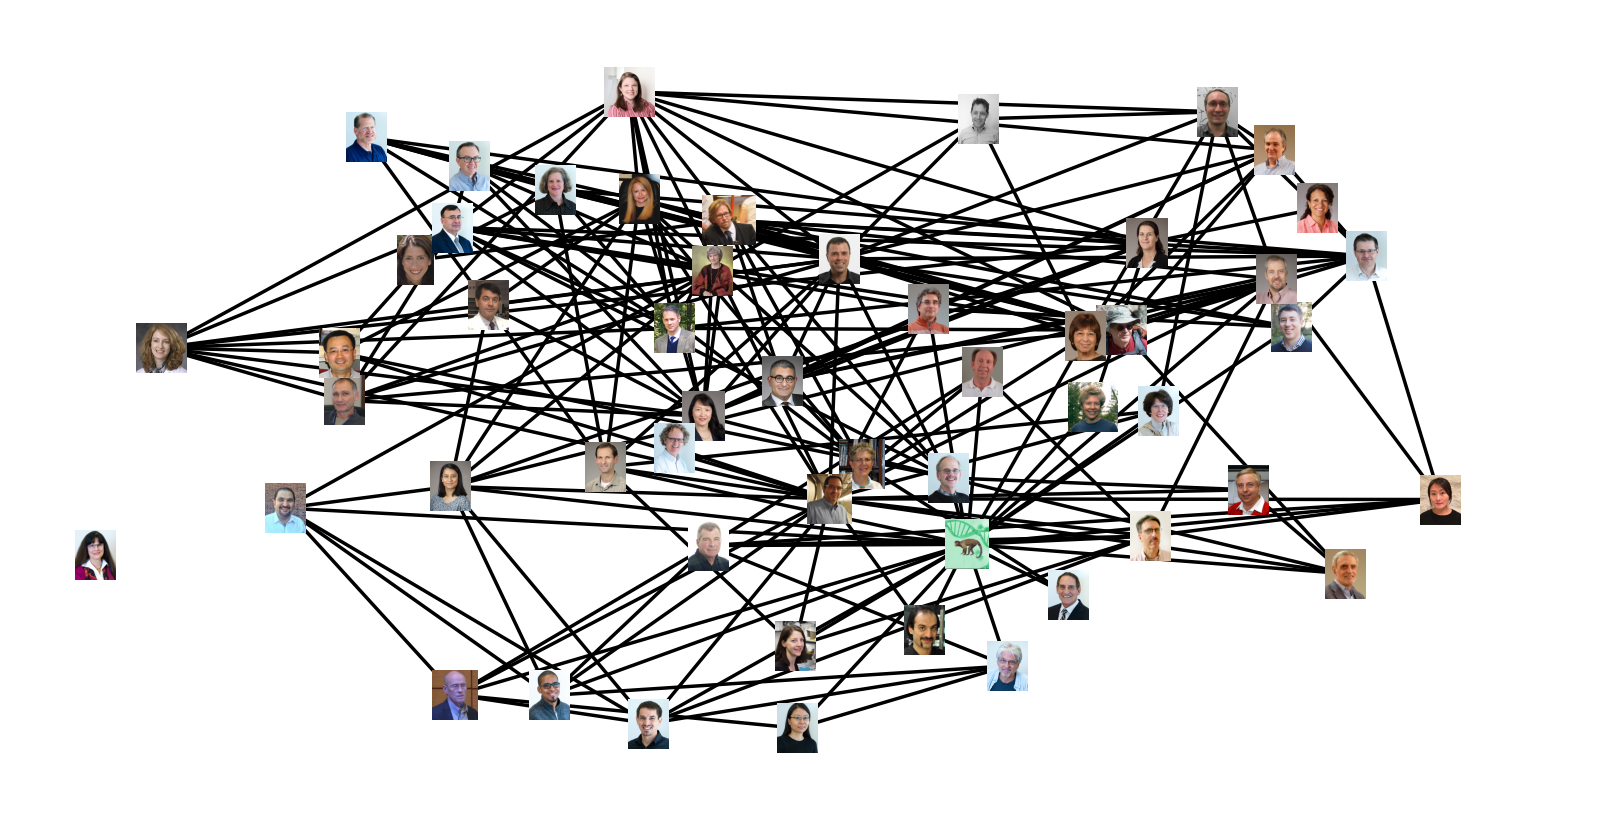

In [311]:
# Based on code from: https://gist.github.com/shobhit/3236373

pos = nx.spring_layout(G, k=1/3, seed=4000)

fig, ax = plt.subplots(1,1, figsize=(8,4), dpi=250)
nx.draw_networkx(G, ax=ax, font_size=5, pos=pos, with_labels=False, node_size=100, node_color='white')
#ax.set_xlim((-1, 1))
trans = ax.transData.transform
trans2 = fig.transFigure.inverted().transform
imsize = 0.05 # this is the image size
for nn in G.nodes:
    (x,y) = pos[nn]
    xx,yy = trans((x,y)) # figure coordinates
    xa,ya = trans2((xx,yy)) # axes coordinates
    img_path = G.nodes[nn]['img']
    img = Image.open(img_path)
    a = plt.axes([xa-imsize/2.0,ya-imsize/2.0, imsize, imsize ])
    a.imshow(img)
    a.axis('off')
    ax.axis('off')
fig.savefig(fig_path / f'irp_collaborations_FY{FY}.png', transparent=True)

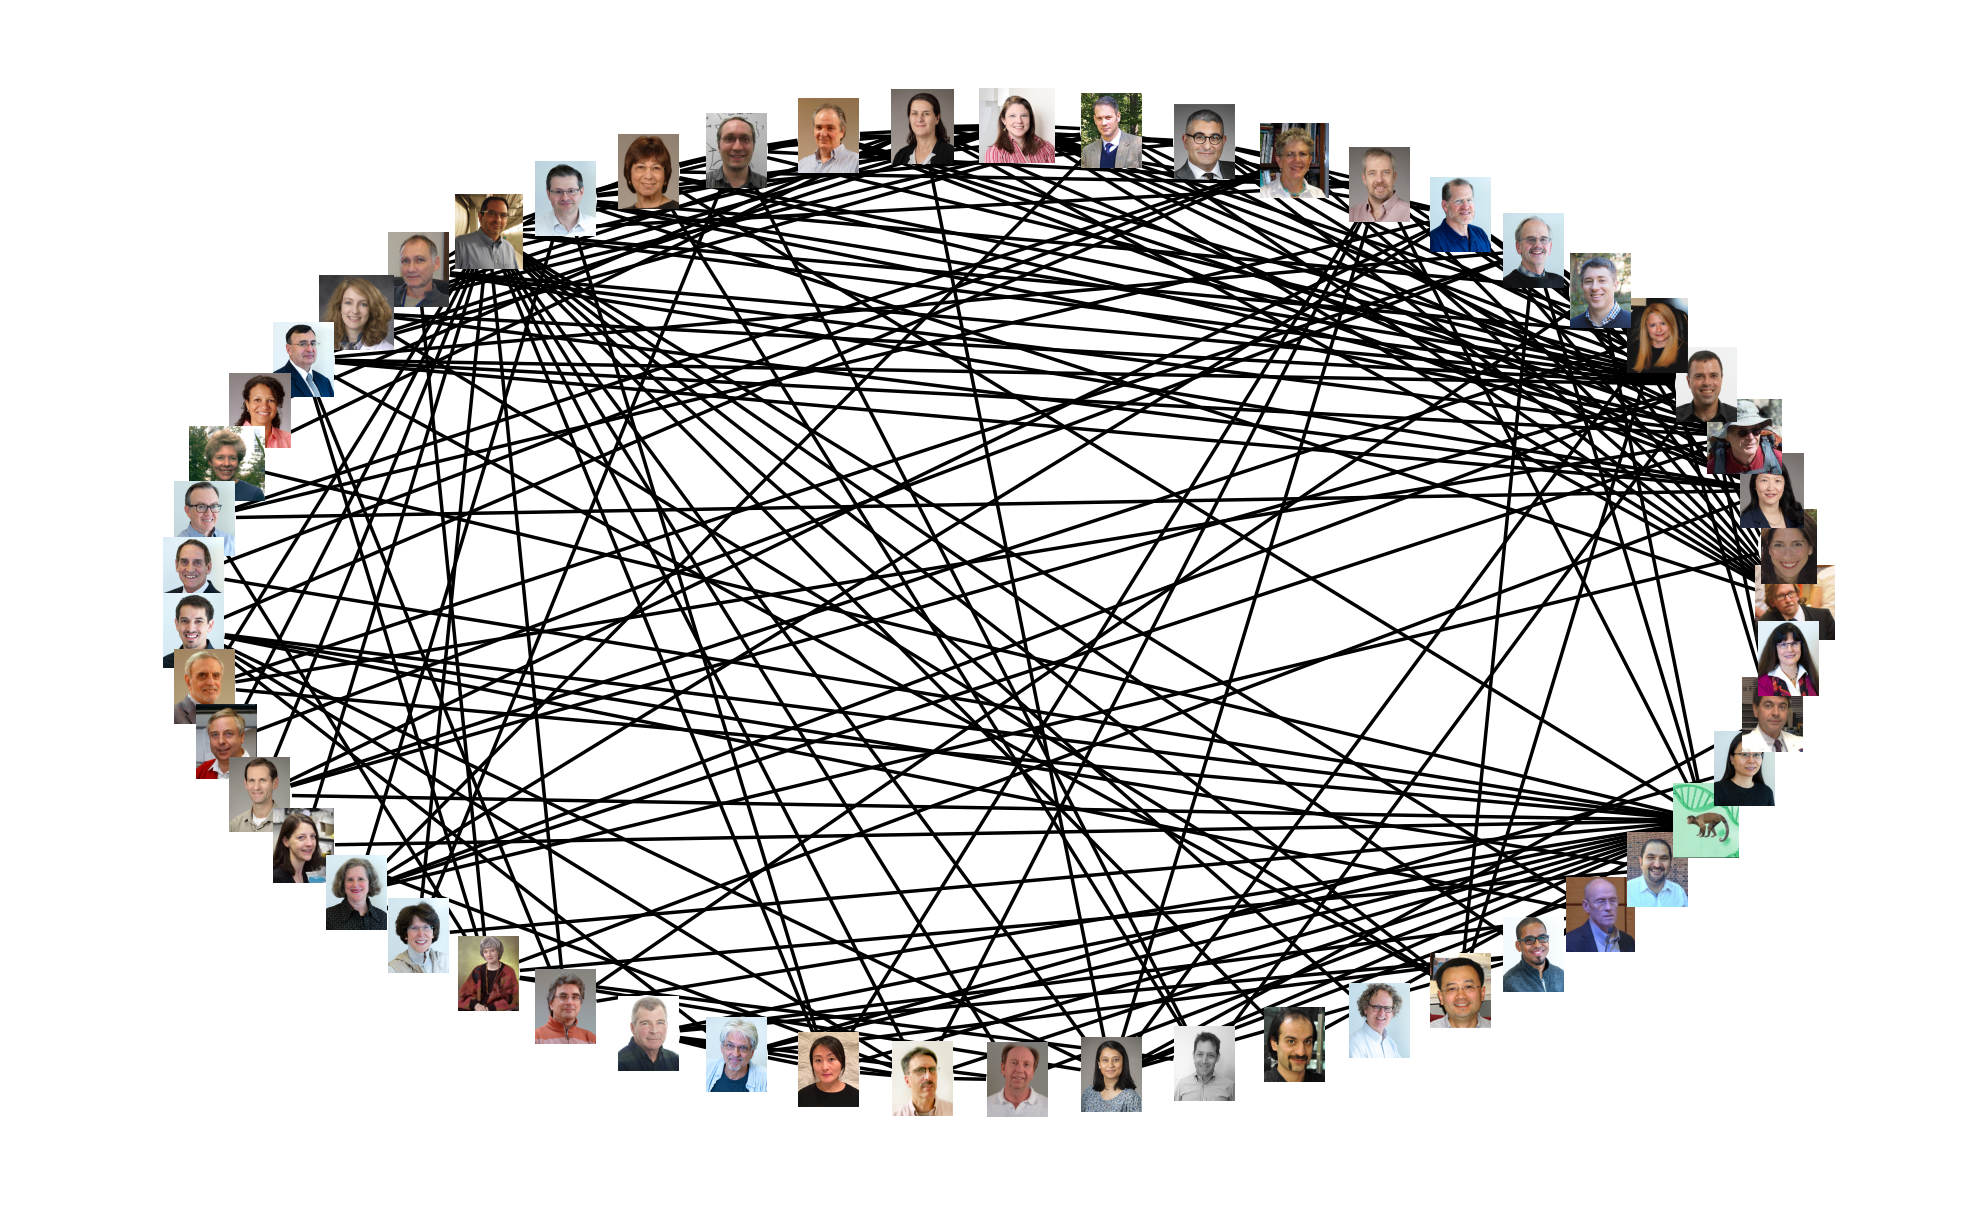

In [312]:
pos = nx.circular_layout(G)
fig, ax = plt.subplots(1,1, figsize=(10,6), dpi=250)
nx.draw_networkx(G, ax=ax, font_size=5, pos=pos, with_labels=False, node_size=300, node_color='white')
#ax.set_xlim((-1, 1))
trans = ax.transData.transform
trans2 = fig.transFigure.inverted().transform
imsize = 0.05 # this is the image size
for nn in G.nodes:
    (x,y) = pos[nn]
    xx,yy = trans((x,y)) # figure coordinates
    xa,ya = trans2((xx,yy)) # axes coordinates
    img_path = G.nodes[nn]['img']
    img = Image.open(img_path)
    a = plt.axes([xa-imsize/2.0,ya-imsize/2.0, imsize, imsize ])
    a.imshow(img)
    a.axis('off')
    ax.axis('off')
fig.savefig(fig_path / f'irp_collaborations_circle_FY{FY}.png', transparent=True)

## Make graph for external collaborators

In [314]:
pi_collab.query('scope == "NIH"').institute.unique()

array(['NINDS', 'NHGRI', 'NICHD', 'NEI', 'NIAMS', 'NIBIB', 'NIDCR', 'CC',
       'NHLBI', 'NIAID', 'NIA', 'NIAAA', 'NIDA', 'NIDDK', 'NINR', 'NCATS',
       'NCCIH', 'CIT', 'OD', 'NCI', 'NIDCD'], dtype=object)

In [315]:
pi_collab['institute'] = pi_collab['institute'].str.strip()

In [ ]:
pi_collab.sample()

In [316]:
x_el = pi_collab.loc[pi_collab.scope=='NIH', ['pi', 'institute']].drop_duplicates().sample(frac=1).to_records(index=False)
x_G = nx.Graph()
x_G.add_edges_from(x_el)

In [317]:
pis = pi_collab.loc[pi_collab.scope=='NIH', 'pi'].unique()
institutes = pi_collab.loc[pi_collab.scope=='NIH', 'institute'].unique()
shells = [institutes,
          pis]

In [318]:
for nn in x_G.nodes:
    try:
        x_G.nodes[nn]['img'] = pic_lut[nn]
    except KeyError:
        pass

In [319]:
palette = sns.color_palette(palette='dark', n_colors=len(institutes))
palette = sns.hls_palette(len(institutes), l=.3, s=.8)
inst_color_lut = {inst:color for inst,color in zip(institutes, palette)}

In [320]:
# Make node color list
node_colors = []
for nn in x_G.nodes:
    if nn in institutes:
        node_colors.append(inst_color_lut[nn]) 
    else:
        node_colors.append((1,1,1))
        
# Make edge color list
edge_colors = []
for n1,n2 in x_G.edges:
    if n1 in institutes:
        edge_colors.append(inst_color_lut[n1])
    else:
        edge_colors.append(inst_color_lut[n2])

In [321]:
# External Stats
n_with_NIH = (pj_df.groupby('PI').NIH_collab.count() > 0).sum()
n_no_NIH = (pj_df.groupby('PI').NIH_collab.count() == 0).sum()
total_collabs = pi_collab.query('scope == "NIH"').shape[0]
total_institutes = pi_collab.query('scope == "NIH"').institute.nunique()

print(f"Total number of collabs: {total_collabs}")
print(f"Unique Institutes: {total_institutes}")
print(f"Number of investigators with non-NIMH IRP collaborators: {n_with_NIH}")
print(f"Number of investigators without non-NIMH IRP collaborators: {n_no_NIH}")

print(f"Mean number of collabs per PI with collabs: {total_collabs/n_with_NIH}")
print(f"Mean number of collabs per all PIs: {total_collabs/n_pi}")
print(f"Mean number of collabs per all PIs but not training: {total_collabs/(n_pi - 1)}")

Total number of collabs: 290
Unique Institutes: 21
Number of investigators with non-NIMH IRP collaborators: 44
Number of investigators without non-NIMH IRP collaborators: 11
Mean number of collabs per PI with collabs: 6.590909090909091
Mean number of collabs per all PIs: 5.2727272727272725
Mean number of collabs per all PIs but not training: 5.37037037037037


In [233]:
# old stats
# External Stats
# n_with_NIH = (pj_df.groupby('PI').NIH_collab.count() > 0).sum()
# n_no_NIH = (pj_df.groupby('PI').NIH_collab.count() == 0).sum()
# total_collabs = pi_collab.query('scope == "NIH"').shape[0]
# total_institutes = pi_collab.query('scope == "NIH"').institute.nunique()

# print(f"Total number of collabs: {total_collabs}")
# print(f"Unique Institutes: {total_institutes}")
# print(f"Number of investigators with non-NIMH IRP collaborators: {n_with_NIH}")
# print(f"Number of investigators without non-NIMH IRP collaborators: {n_no_NIH}")

# print(f"Mean number of collabs per PI with collabs: {total_collabs/n_with_NIH}")
# print(f"Mean number of collabs per all PIs: {total_collabs/n_pi}")
# print(f"Mean number of collabs per all PIs but not training: {total_collabs/(n_pi - 1)}")

Total number of collabs: 303  
Unique Institutes: 20  
Number of investigators with non-NIMH IRP collaborators: 46  
Number of investigators without non-NIMH IRP collaborators: 11  
Mean number of collabs per PI with collabs: 6.586956521739131  
Mean number of collabs per all PIs: 5.315789473684211  
Mean number of collabs per all PIs but not training: 5.410714285714286  

In [322]:
(pj_df.groupby('PI').NIH_collab.count())[(pj_df.groupby('PI').NIH_collab.count() == 0)]

PI
Argyrios  Stringaris, PhD    0
Armin  Raznahan, PhD         0
Bruno B Averbeck, PhD        0
Christian  Grillon, PhD      0
Daniel  Pine, MD             0
Dietmar  Plenz, PhD          0
Elisha Prem Merriam, PhD     0
Heather A Cameron, PhD       0
Janet Elizabeth Clark        0
Leslie G Ungerleider, PhD    0
Melissa A Brotman, PhD       0
Name: NIH_collab, dtype: int64

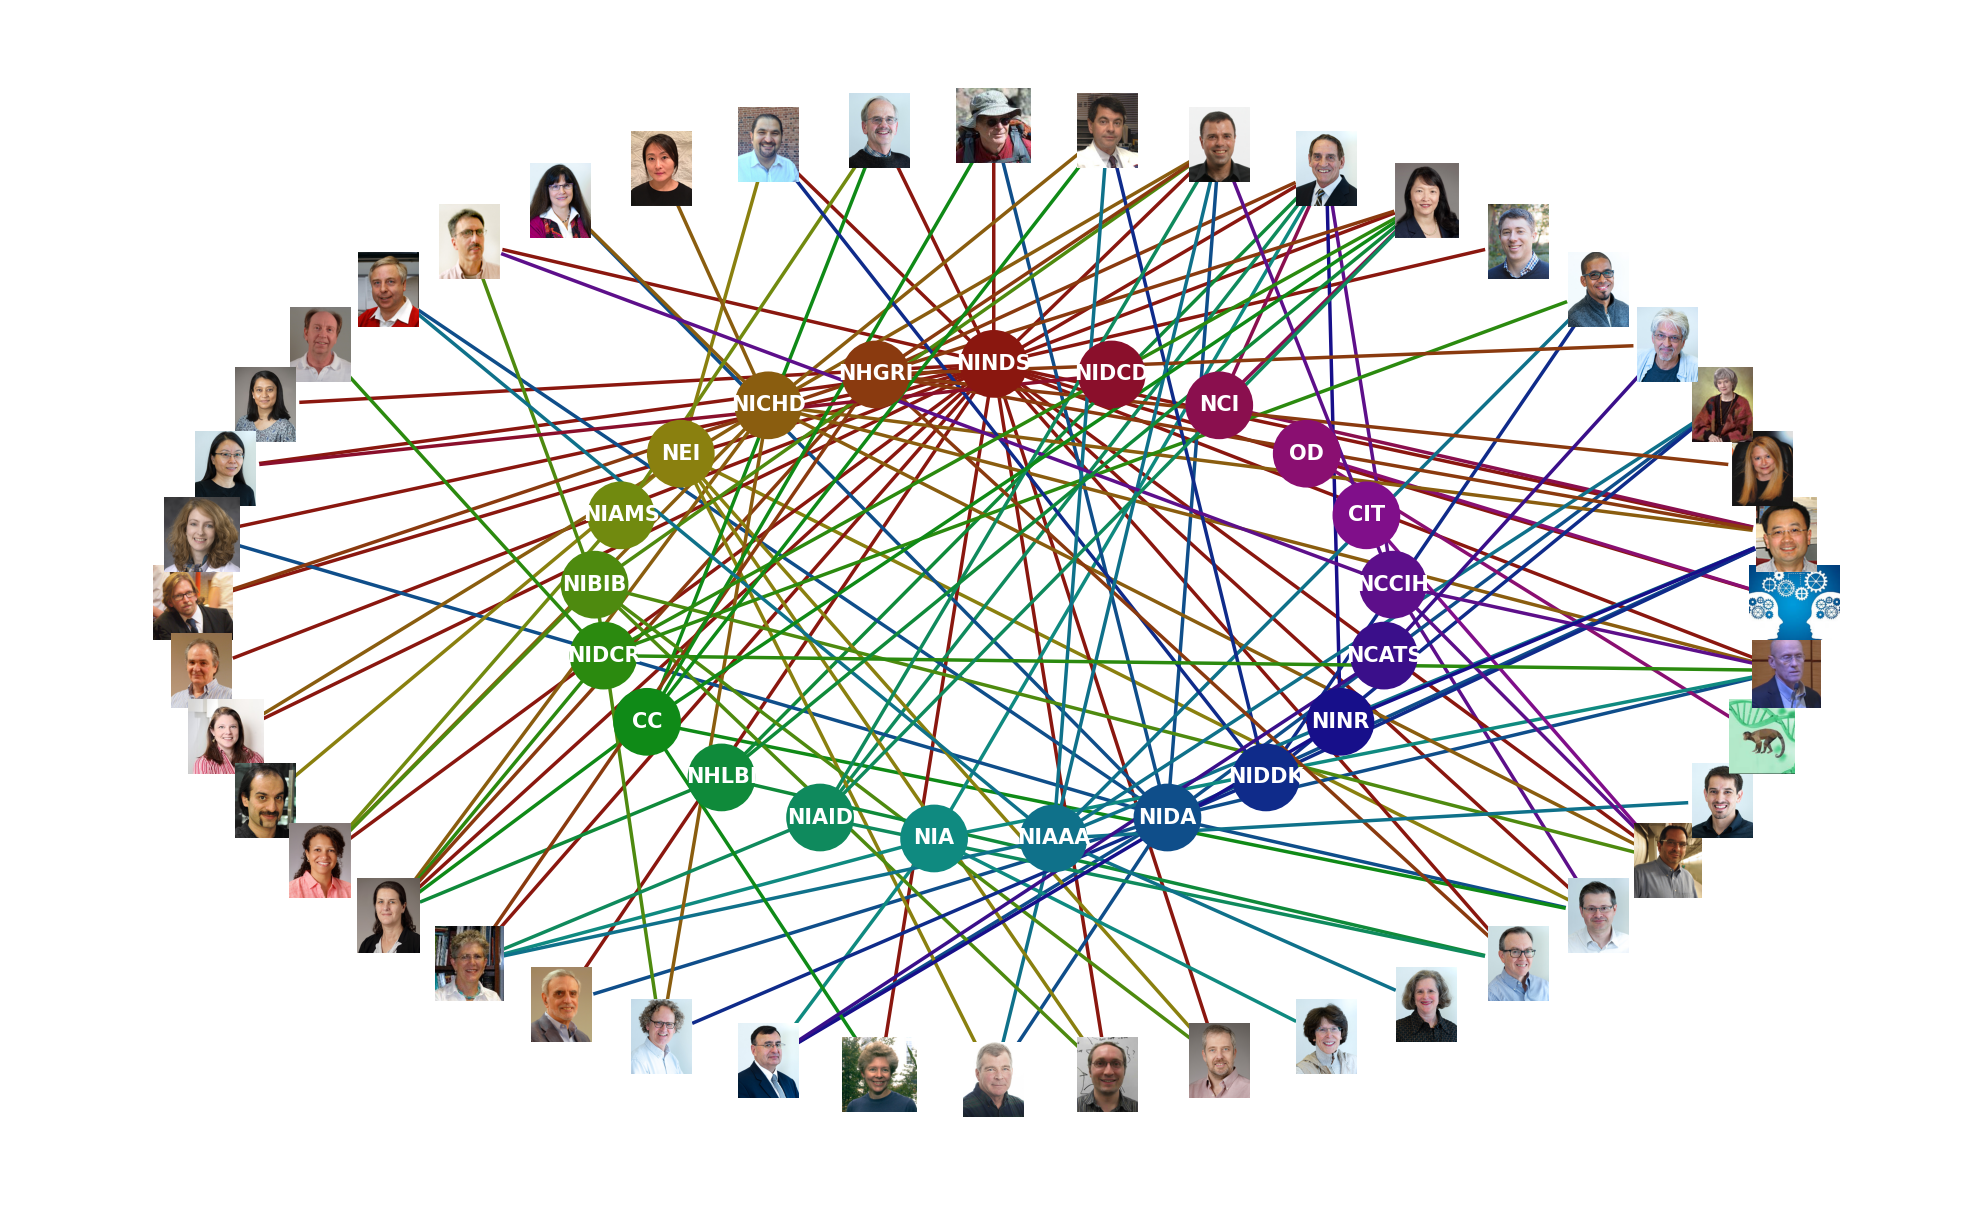

In [323]:
pos = nx.shell_layout(x_G, nlist=shells)
fig, ax = plt.subplots(1,1, figsize=(10,6), dpi=250)
nx.draw_networkx(x_G, ax=ax, font_size=5, pos=pos, with_labels=False, node_size=350, node_color=node_colors, edge_color=edge_colors)
trans = ax.transData.transform
trans2 = fig.transFigure.inverted().transform
imsize = 0.05
for nn in pis:
    (x,y) = pos[nn]
    xx,yy = trans((x,y)) # figure coordinates
    xa,ya = trans2((xx,yy)) # axes coordinates
    img_path = x_G.nodes[nn]['img']
    img = Image.open(img_path)
    a = plt.axes([xa-imsize/2.0,ya-imsize/2.0, imsize, imsize ])
    a.imshow(img)
    a.axis('off')
ax.axis('off')
for nn in institutes:
    (x,y) = pos[nn]
    xx,yy = trans((x,y)) # figure coordinates
    xa,ya = trans2((xx,yy)) # axes coordinates
    ax.text(x, y, nn, color='white', size=6, ha='center', va='center', weight='bold')
    
fig.savefig(fig_path / f'nih_collaborations_circle_FY{FY}.png', transparent=True)

# save csv for collabs

In [325]:
pi_collab.to_csv(collab_table, index=None)

# Trend across analysis rounds


In [ ]:
# Published totals from the two prior rounds (see ANALYSIS.md). FY2018 and
# FY2021 are the numbers as delivered; the current FY's bars are computed from
# this run so the figure can never disagree with the stats cells above.
published = {2018: {'NIMH': 326, 'NIH': 303, 'EM': 470},
             2021: {'NIMH': 332, 'NIH': 290, 'EM': 464}}
current = pi_collab.scope.value_counts().to_dict()
years = sorted(published) + [FY]
scopes = [('NIMH', 'Within NIMH'), ('NIH', 'Other NIH ICs'), ('EM', 'External')]

# Year is ordinal, so it gets a light-to-dark sequential ramp, not three
# unrelated hues. Lightest bar sits below 3:1 contrast, so every bar carries a
# direct value label.
year_colors = {years[0]: '#A8CCE8', years[1]: '#4E8FC4', years[2]: '#124E7E'}

fig, ax = plt.subplots(figsize=(8, 4.2), dpi=250)
width = 0.26
for j, year in enumerate(years):
    vals = [published.get(year, current)[k] for k, _ in scopes]
    xs = [i + (j - 1) * (width + 0.02) for i in range(len(scopes))]
    bars = ax.bar(xs, vals, width, color=year_colors[year], label=f'FY{year}', zorder=3)
    for x, v in zip(xs, vals):
        ax.text(x, v + 8, str(v), ha='center', va='bottom', fontsize=9, color='#333333')

ax.set_xticks(range(len(scopes)))
ax.set_xticklabels([lbl for _, lbl in scopes], fontsize=11)
ax.set_ylabel('Reported collaborations', fontsize=10)
ax.set_ylim(0, 640)
ax.yaxis.grid(True, color='#DDDDDD', linewidth=0.8, zorder=0)
ax.tick_params(axis='y', labelsize=9, length=0)
ax.tick_params(axis='x', length=0)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#BBBBBB')
ax.legend(frameon=False, fontsize=10, loc='upper left')
fig.tight_layout()
# White background, not transparent: some renderers composite RGBA
# poorly, and the deck's stat panels are white anyway.
fig.savefig(fig_path / f'collab_trend_FY{FY}.png', facecolor='white')
